In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
df = pd.read_csv('data.csv')
features = ['surface_m2']
n_features = len(features)
#prepare data
data = df



idx_train = data.sample(frac = 0.8).index

X_train = data.loc[idx_train,features].values
Y_train = data.loc[idx_train,'price'].values

X_test = data.drop(idx_train).loc[:,features].values
Y_test = data.drop(idx_train)['price'].values

df.describe()

,property_id,photo_count,price,old_price,discount_percentage,bedrooms,surface_m2
count,4.830000e+02,480.000000,4.830000e+02,2.100000e+01,21.000000,478.000000,483.000000
mean,1.052446e+08,42.189583,4.162659e+05,4.888651e+05,11.238095,3.389121,186.314700
std,9.261150e+06,29.241266,2.848194e+05,3.939707e+05,5.872859,2.069861,139.847236
min,2.078240e+06,1.000000,4.999000e+04,1.090000e+05,3.000000,1.000000,25.000000
25%,1.045019e+08,21.000000,2.240000e+05,2.300000e+05,7.000000,2.000000,95.000000
50%,1.078651e+08,37.500000,3.300000e+05,3.750000e+05,12.000000,3.000000,156.000000
75%,1.091941e+08,55.000000,5.499990e+05,5.200000e+05,15.000000,4.000000,226.500000
max,1.099958e+08,179.000000,1.750000e+06,1.234567e+06,20.000000,20.000000,1182.000000


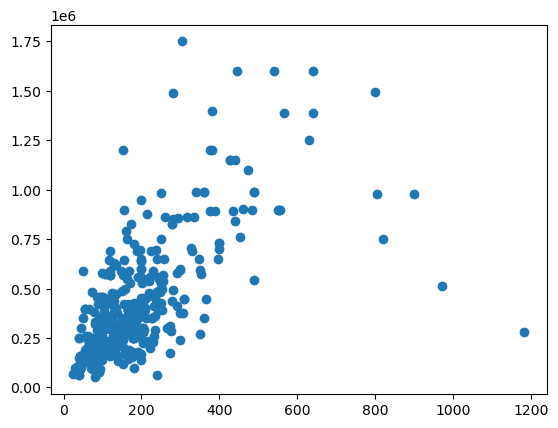

In [118]:
plt.scatter(X_train,Y_train)

# FEATURES SCALING

In [119]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled

array([[-9.84579633e-01],
       [ 8.00176058e-02],
       [ 8.67555630e-02],
       [-2.50142297e-01],
       [ 1.26589807e+00],
       [-1.02500738e+00],
       [ 1.94562878e-01],
       [-1.00479350e+00],
       [ 7.60551284e-01],
       [ 2.00707337e+00],
       [ 6.72957840e-01],
       [-9.64365762e-01],
       [ 3.02450491e+00],
       [ 5.30657770e-02],
       [-9.51692816e-02],
       [ 1.67691346e+00],
       [-6.54419730e-01],
       [-7.15061345e-01],
       [ 4.37129338e-01],
       [ 2.21514707e-01],
       [-5.80302201e-01],
       [-4.18591228e-01],
       [-1.01907239e-01],
       [-8.22868660e-01],
       [-1.82762725e-01],
       [ 1.87824921e-01],
       [ 1.27183306e-01],
       [-6.54419730e-01],
       [ 5.30657770e-02],
       [-1.69286811e-01],
       [ 1.13113893e+00],
       [ 1.26589807e+00],
       [-6.82174528e-02],
       [-5.39874457e-01],
       [-8.09392746e-01],
       [-6.20729944e-01],
       [-1.01153146e+00],
       [ 6.66973976e+00],
       [ 2.4

In [120]:
Y_train = Y_train.reshape([X_train.shape[0],1])

X_trainb = np.hstack([X_train_scaled,np.ones((X_train.shape[0],1))])

# Polynomial application

In [121]:
from sklearn.preprocessing import PolynomialFeatures
X_poly = PolynomialFeatures(degree=3, include_bias=False).fit_transform(X_train)
X_test_poly = PolynomialFeatures(degree=3, include_bias=False).fit_transform(X_test)
X_poly.shape[1]

3

# LINEAR REGRESSION CLASS

In [122]:
class LR :
    def __init__(self,n_features,ridge_lamda = 0):
        self.w = np.random.randn(n_features,1)
        self.costs = []
        self.lamda = ridge_lamda

    def predict(self,X):
        return X@self.w

    def cost(self, X,y):
        m = len(y)
        ridge = self.lamda * np.sum(self.w **2)
        return (1/(2*m)) * (np.sum((X@self.w - y) **2) + ridge)

    def grad(self,X,y):
        m = len(y)
        ridge = self.lamda * self.w
        return (1/m) * ( X.T.dot(X@self.w - y) + ridge)

    def descente_gradient(self,X,y,alpha,n_iterations):
        for i in range(0,n_iterations):
            self.w = self.w -alpha * self.grad(X,y)
            self.costs.append(self.cost(X,y))

    def fit_analytique(self,X,y):
        self.w = 0
        self.w = np.linalg.inv(X.T@X).dot(X.T@y)
        

In [123]:
# lr = LR(X_poly.shape[1])
# lr.descente_gradient(X_poly,Y_train,alpha=0.1,n_iterations=1000)

lr2 = LR(n_features)
lr2.fit_analytique(X_poly,Y_train)

# predictions =lr.predict(X_poly)
predictions2  = lr2.predict(X_poly)

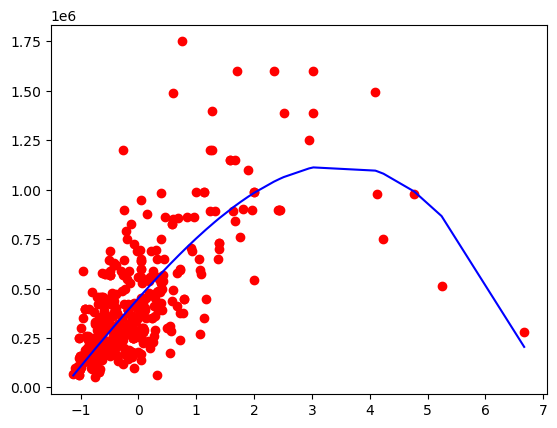

In [124]:
idx = np.argsort(X_train_scaled[:,0])

X_sorted = X_train_scaled[idx]
pred_sorted = predictions2[idx]

plt.scatter(X_train_scaled, Y_train, c='red')
plt.plot(X_sorted, pred_sorted, color='blue')

In [127]:
from sklearn.metrics import r2_score

prediction_test = lr2.predict(X_test_poly)
df = pd.DataFrame({
    'prediction' : [r2_score(Y_train,predictions2)],
    'prediction_test' : [r2_score(Y_test,prediction_test)]
    })
df

,prediction,prediction_test
0,0.542574,0.348584


# sklearn model

In [126]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

model = make_pipeline(StandardScaler(), LinearRegression())
model.fit(X_train, Y_train)

pred = model.predict(X_train)
pred_test = model.predict(X_test)

print('test' + str(r2_score(Y_test,pred_test)))
print('train:' + str(r2_score(Y_train, pred)))

test0.41686978568785493
train:0.4313120737045609
